In [183]:
# USA AIRLINES TWITTER REVIEWS
# Name: Maria Gracia Albrecht Carter

# The dataset used in this assignment is composed of tweets about several US airlines, such as Delta, American Airlines and United Airlines.
# The tweets have already been labeled with a sentiment (positive, negative and neutral), and at the same time, the negative tweets have been labeled with a reason
# for the negative review (Bad Flight, Bad Customer Service, etc.).
# For the assignment, we will focus on classifying the negative reviews according to the reason behind them.

# The purpose of this assignment is to look at how techniques such as zero-shot and few-shot can be used to classify text data.
# In this case, the dataset originally came with labels, but these are useful in order to evaluate the performance of the classifier.
# This analysis can be useful, because airlines or other companies could use similar techniques to classify their customer reviews.
# While it is very useful to know if the sentiments are positive or negative, it is even more useful to identify the reasons behind negative reviews.
# I will be using OLLAMA as the LLM for this assignment.

# Source of the data set: https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

In [184]:
# Install necessary Python packages
!pip install ollama pandas scikit-learn tqdm seaborn -q

# Install Ollama runtime
#!curl -fsSL https://ollama.com/install.sh | sh

# Code taken from the m2_nlp_ollama.ipynb notebook shown in class

In [185]:
# Use if necessary

#import os, subprocess, time
#os.environ['PATH'] += ':/usr/local/cuda/bin'
#os.environ['LD_LIBRARY_PATH'] = '/usr/lib64-nvidia:/usr/local/cuda/lib64'
#subprocess.Popen(["ollama","serve"])
#time.sleep(3)

# Code taken from the m2_nlp_ollama.ipynb notebook shown in class

In [186]:
# For Windows, use if necessary: Ollama runs as a background service

#import platform

#def start_ollama():
    #if platform.system() == "Windows":
        #print("🪟 Windows detected: assuming Ollama service is already running.")
        #return None
    #...

# Code obtained from Chat GPT

In [187]:
# Necessary imports

import subprocess
import time
import requests
import json
import os
import pandas as pd
import ollama
from pydantic import BaseModel, Field, ValidationError
from typing import List, Literal, Optional
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the model name as a constant to be reused
MODEL_NAME = "qwen3:latest"

# Code taken from the m2_nlp_ollama.ipynb notebook shown in class

In [188]:
def start_ollama():
    """Starts the Ollama server and waits for it to become ready."""
    import subprocess, time, requests
    # Start the server as a background process
    p = subprocess.Popen(["ollama", "serve"])
    print("🚀 Starting Ollama server...")
    # Poll the API endpoint until it's ready
    for _ in range(30):
        try:
            r = requests.get("http://localhost:11434/api/tags", timeout=1)
            if r.status_code == 200:
                print("✅ Ollama server is live and ready.")
                return p
        except (requests.exceptions.ConnectionError, requests.exceptions.ReadTimeout):
            time.sleep(1)
    raise RuntimeError("Ollama server did not start within the expected time.")

# Start the server
server_process = start_ollama()

# Code taken from the m2_nlp_ollama.ipynb notebook shown in class

🚀 Starting Ollama server...
✅ Ollama server is live and ready.


In [189]:
# Pulling the model
#| output: true
print("--- Installed Models (Before Pull) ---")
!ollama list

# Pull the model from the Ollama registry
print(f"\n--- Pulling {MODEL_NAME} ---")
!ollama pull {MODEL_NAME}

# Verify that the model is now available locally
print(f"\n--- Installed Models (After Pull) ---")
!ollama list

# Code taken from the m2_nlp_ollama.ipynb notebook shown in class

--- Installed Models (Before Pull) ---
NAME            ID              SIZE      MODIFIED      
qwen3:latest    500a1f067a9f    5.2 GB    7 minutes ago    

--- Pulling qwen3:latest ---

--- Installed Models (After Pull) ---


pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest 
pulling a3de86cd1c13: 100% ▕██████████████████▏ 5.2 GB                         
pulling ae370d884f10: 100% ▕██████████████████▏ 1.7 KB                         
pulling d18a5cc71b84: 100% ▕██████████████████▏  11 KB                         
pulling cff3f395ef37: 100% ▕██████████████████▏  120 B                         
pulling 05a61d37b084: 100% ▕██████████████████▏  487 B                         
verifying sha256 digest 
writing manifest 
success 


NAME            ID              SIZE      MODIFIED               
qwen3:latest    500a1f067a9f    5.2 GB    Less than a second ago    


In [190]:
# Testing the LLM
hello_resp = ollama.chat(
    model=MODEL_NAME,
    messages=[{"role": "user", "content": "Say hello in one short sentence."}],
    stream=False,
    think=False
)

print(hello_resp["message"]["content"])

# Code taken from the m2_nlp_ollama.ipynb notebook shown in class

Hello!


In [191]:
#Loading the dataset
url = "https://raw.githubusercontent.com/satyajeetkrjha/kaggle-Twitter-US-Airline-Sentiment-/master/Tweets.csv"
df = pd.read_csv(url)

# Display the first few rows of the dataset
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [192]:
# Checking for missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [193]:
# The most important variables for the analysis are "airline_sentiment" and "text", and they do not have missing values.
# However, for EDA, it will be a problem if there are missing values in other columns.

# I will eliminate airline_sentiment_gold and negativereason_gold because they have mostly missing values and they don't need to be used in the analysis
df = df.drop(columns=['airline_sentiment_gold', 'negativereason_gold'])

# For "negativereason", I want to be sure that those missing values belong to positive and neutral sentiments only.
df.loc[df['negativereason'].isna(), 'airline_sentiment'].value_counts(normalize=True) #obtained from ChatGPT

airline_sentiment
neutral     0.567375
positive    0.432625
Name: proportion, dtype: float64

In [194]:
# With this result, we confirm that all missing values in "negativereason" correspond to positive and neutral sentiments.
# This means that for EDA, we cannot analyze "negativereason" for positive and neutral sentiments.

In [195]:
# Checking for duplicates
print(df.duplicated().sum())

# Dropping duplicates
df = df.drop_duplicates().reset_index(drop=True)

# I have dropped the duplicates because they were not many (around 30), and it is likely they were there due to a mistake.

39


C:\Users\maria\AppData\Local\Temp\ipykernel_28424\1933869658.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='airline_sentiment', palette='viridis')


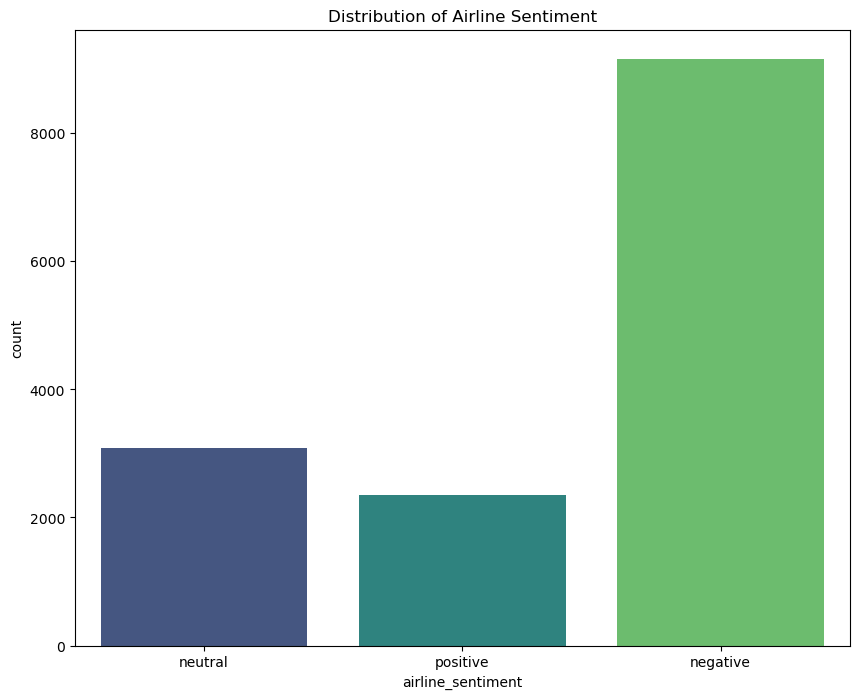

In [196]:
# EDA 

# Sentiment distribution
# Here we will look at the balance between positive, neutral and negative sentiments in the tweets.
# (Graphs made with the aid of Chat GPT)

plt.figure(figsize=(10,8))
sns.countplot(data=df, x='airline_sentiment', palette='viridis')
plt.title("Distribution of Airline Sentiment")
plt.show()

In [197]:
# We can see from the result that most of the tweets have a negative sentiment, and the least have a positive sentiment.

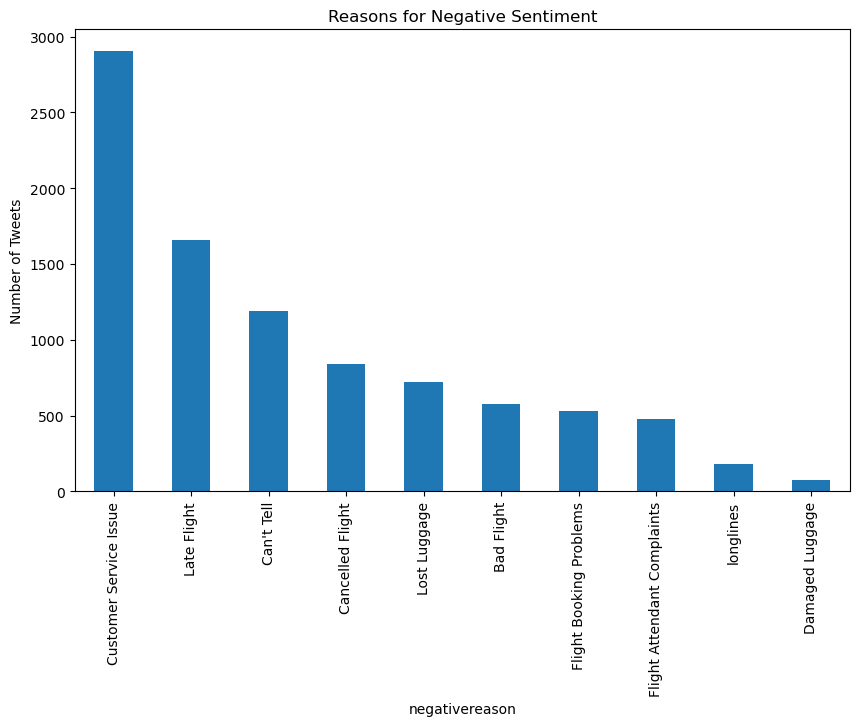

In [198]:
# Looking at the most common reasons for negative sentiments
# For this we need to filter the dataset so that it only includes negative sentiments

neg_reasons = df[df['airline_sentiment'] == 'negative']['negativereason'].value_counts()
neg_reasons.plot(kind='bar', figsize=(10,6))
plt.title("Reasons for Negative Sentiment")
plt.ylabel("Number of Tweets")
plt.show()



In [199]:
# In this dataset, most labelled negative tweets are due to customer service issues, while the least common reason is damaged luggage.
# However, "can't tell" is a label used when the reason behind the negative tweet is not clear. It represents a fair portion of the negative tweets,
# which could indicate that additional issues are not being captures by the existing labels, which could be something to consider for further analysis.

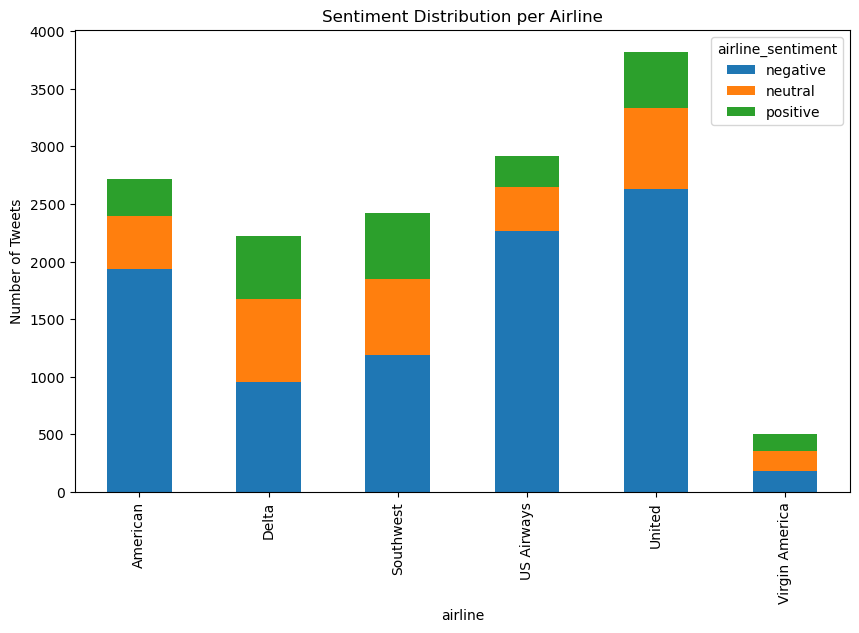

C:\Users\maria\AppData\Local\Temp\ipykernel_28424\2184251590.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=neg_counts, x='airline', y='negative_count', palette='Reds')


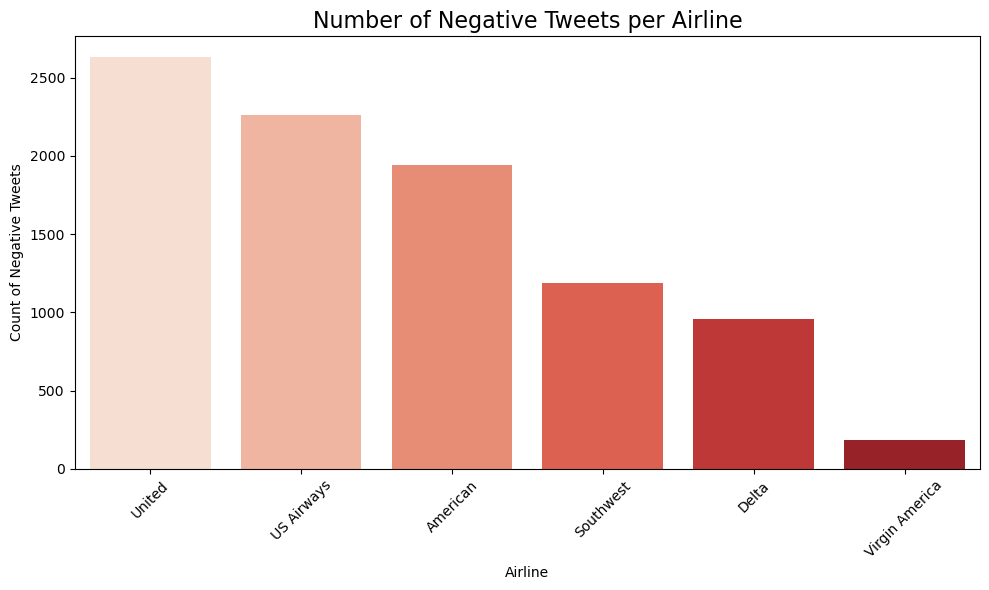

C:\Users\maria\AppData\Local\Temp\ipykernel_28424\2184251590.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=p_counts, x='airline', y='positive_count', palette='Greens')


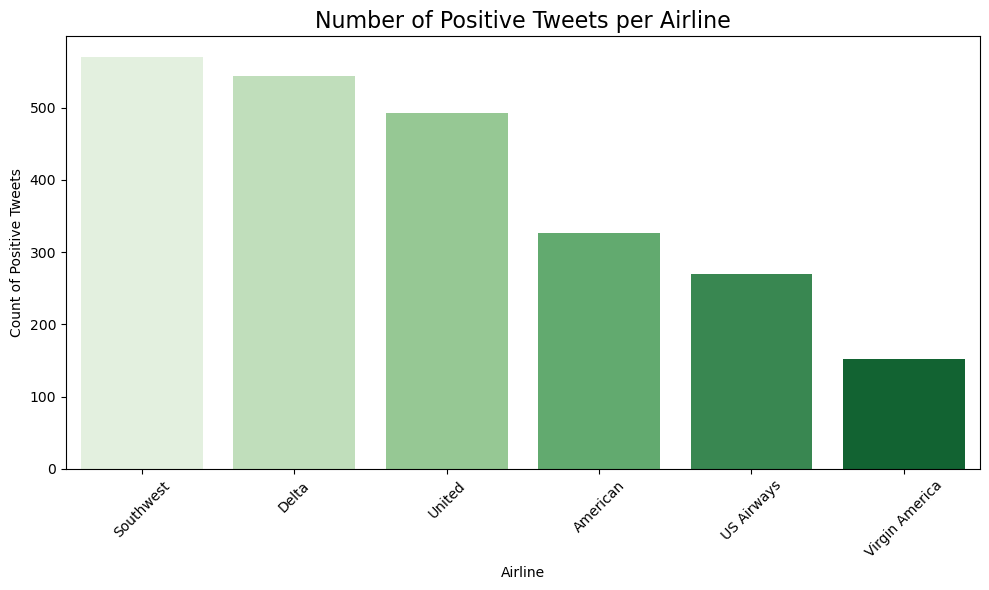

In [200]:
# Sentiment distribution per airline: Looking at which airlines have the most negative, neutral and positive tweets
airline_sentiment_counts = df.groupby(['airline', 'airline_sentiment']).size().unstack(fill_value=0)
airline_sentiment_counts.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title("Sentiment Distribution per Airline")
plt.ylabel("Number of Tweets")
plt.show()

# Only negative sentiments per airline
df_negative = df[df['airline_sentiment'] == 'negative'].copy()
neg_counts = df_negative['airline'].value_counts().reset_index()
neg_counts.columns = ['airline', 'negative_count']

plt.figure(figsize=(10,6))
sns.barplot(data=neg_counts, x='airline', y='negative_count', palette='Reds')
plt.title('Number of Negative Tweets per Airline', fontsize=16)
plt.xlabel('Airline')
plt.ylabel('Count of Negative Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Only positive sentiments per airline
df_positive = df[df['airline_sentiment'] == 'positive']
p_counts = df_positive['airline'].value_counts().reset_index()
p_counts.columns = ['airline', 'positive_count']

plt.figure(figsize=(10,6))
sns.barplot(data=p_counts, x='airline', y='positive_count', palette='Greens')
plt.title('Number of Positive Tweets per Airline', fontsize=16)
plt.xlabel('Airline')
plt.ylabel('Count of Positive Tweets')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [201]:
# In the entire dataset, the airline with the most negative tweets is United, while the airline with the most positive sentiment tweets is Southwest.
# When we look at the proportions, we can see that almost all airlines have a significantly larger proportion of negative tweets compared to positive and neutral ones.
# In the case of Virgin America, the proportion of positive, negative and neutral tweets looks roughly equal.

In [202]:
# ZERO-SHOT CLASSIFICATION AS A BASELINE MODEL

# In this stage, I am going to use zero-shot classification as a baseline. The LLM will classify the negative tweets, but without me giving it any examples.
# We will use a random sample of 1000, because the dataset contains negative sentiment tweets with more than 9,000 entires, and running the model on all of them
# would take some hours.

In [203]:
# Establishing the sample
df_negative = df[df['airline_sentiment'] == 'negative'].sample(1000, random_state=42) # Aided by Chat GPT

In [204]:

# Define the negative reason categories
NEGATIVE_REASONS = [
    "Flight Booking Problems",
    "Cancelled Flight",
    "Late Flight",
    "Customer Service Issue",
    "Lost Luggage",
    "Flight Attendant Complaints",
    "Can't Tell",
    "longlines",
    "Bad Flight",
    "Damaged Luggage"
]

class NegativeReasonPrediction(BaseModel):
    predicted_label: Literal[
        "Flight Booking Problems",
        "Cancelled Flight",
        "Late Flight",
        "Customer Service Issue",
        "Lost Luggage",
        "Flight Attendant Complaints",
        "Can't Tell",
        "longlines",
        "Bad Flight",
        "Damaged Luggage"
    ] = Field(description="The predicted negative reason for the tweet.")

    # Code directly adapted from the m2_nlp_ollama.ipynb notebook shown in class


In [205]:
# Code directly adapted from the m2_nlp_ollama.ipynb notebook shown in class, aided by Chat GPT

def analyze_negative_tweet_zero_shot(tweet: str) -> Optional[str]:
    """Analyzes a negative tweet using zero-shot and returns the predicted label."""
    
    system_prompt = (
        "You classify tweets complaining about US airlines into one of the allowed negative reasons: "
        f"{NEGATIVE_REASONS}. "
        "You MUST return only valid JSON with exactly one field: 'predicted_label'. "
        "Do not include explanations or markdown."
    )
    
    user_prompt = f"Analyze this tweet:\n\n{tweet}"

    try:
        response = ollama.chat(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ],
            format=NegativeReasonPrediction.model_json_schema(), # Enforce the schema
            stream=False,
            think=False
        )
        raw_json = response["message"]["content"]
        result = NegativeReasonPrediction.model_validate_json(raw_json)
        return result.predicted_label
    except (ValidationError, json.JSONDecodeError, KeyError) as e:
        print(f"Error processing tweet: {e}")
        return None


In [206]:

# Make predictions for negative sentiment tweets only
predictions = []
for tweet, true_label in tqdm(zip(df_negative['text'], df_negative['negativereason']), desc="Zero-Shot Classification"):
    predicted = analyze_negative_tweet_zero_shot(tweet)
    predictions.append({
        "tweet": tweet,
        "true_label": true_label,
        "predicted_label": predicted if predicted else "Error"
    })

df_baseline = pd.DataFrame(predictions)
df_baseline_valid = df_baseline[df_baseline['predicted_label'] != "Error"]

print("\n--- 📊 Zero-Shot Predictions for Negative Tweets ---")
display(df_baseline_valid.head())

# Evaluation

y_true = df_baseline_valid['true_label']
y_pred = df_baseline_valid['predicted_label']

baseline_accuracy = accuracy_score(y_true, y_pred)
print(f"\n--- 🎯 Baseline Zero-Shot Performance ---")
print(f"Overall Accuracy: {baseline_accuracy:.2%}\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, labels=NEGATIVE_REASONS, zero_division=0))

# Code directly adapted from the m2_nlp_ollama.ipynb notebook shown in class, aided by Chat GPT



Zero-Shot Classification: 1000it [22:29,  1.35s/it]


--- 📊 Zero-Shot Predictions for Negative Tweets ---


,tweet,true_label,predicted_label
0,@united I would take the $500 voucher you offered for MISCOUNTING THE # OF SEATS ON YOUR PLANE but that means I would have to fly you again,Can't Tell,Flight Booking Problems
1,"@AmericanAir can you do anything to get #AA953 moving? Been almost 24 hrs and hundreds at jfk upset, tired and want to get to BA.",Late Flight,Late Flight
2,@united no still trying to get home.,Late Flight,Can't Tell
3,"Too little, too Late Flight. You suck RT @USAirways: @mitchsunderland Oh no, Mitchell. Our agents are happy to offer you available options.",Can't Tell,Late Flight
4,@SouthwestAir why do your MDW gates have so many fewer seats than your planes?,longlines,Can't Tell



--- 🎯 Baseline Zero-Shot Performance ---
Overall Accuracy: 54.20%

Classification Report:
                             precision    recall  f1-score   support

    Flight Booking Problems       0.28      0.61      0.38        56
           Cancelled Flight       0.51      0.82      0.63        92
                Late Flight       0.78      0.56      0.65       189
     Customer Service Issue       0.62      0.66      0.64       343
               Lost Luggage       0.64      0.82      0.72        61
Flight Attendant Complaints       0.29      0.12      0.17        60
                 Can't Tell       0.42      0.20      0.27       132
                  longlines       0.21      0.36      0.26        22
                 Bad Flight       0.27      0.16      0.20        38
            Damaged Luggage       1.00      0.14      0.25         7

                   accuracy                           0.54      1000
                  macro avg       0.50      0.45      0.42      1000
          

In [207]:
# The baseline model predicts the reason (category) behind the negative tweets with an accuracy of roughly 54%, for a random sample of 1000 tweets.
# I was not expecting it to be completely accurate because in zero-shot, the LLM has not been trained yet to classify into the correct labels.
# The precision and recall scores are higher for some of the labels (e.g. Customer service issue, Lost Luggage) and lower for others (Bad Flight, Flight Attendand Complaints)
# According to what we have discussed in class in previous topics, a high precision indicates that out of all the tweets the classifier classified as a certain label, a high amount will actually belong to that label.
# For example, when the model classifies that a negative tweet is about Customer Service Issue, it will be right 62% of the time.
# On the other hand, in this context, a high recall indicates that out of all the negative tweets that belong to a certain "reasons" label, the model can identify most.
# Overall, the model is generally good at classifying negative tweets into the high precison and high recall labels, and not so good sorting those in the low recall
# and low precision labels. It might not be good with those categories because maybe it cannot distinguish them.

# For the next part, I will implement a a few-shot classification, in which I will aim to improve the model by tuning it with a labelled example.
# Because of this, I expect the model to perform better than the baseline.

In [208]:
# Improvement: few-shot guidance and compressed output

CATEGORY_MAP = {name: i for i, name in enumerate(NEGATIVE_REASONS)}
ID_TO_CATEGORY = {i: name for name, i in CATEGORY_MAP.items()}

class MinimalNegativeReason(BaseModel):
    """Minimal schema for fast classification using an integer ID."""
    category_id: int = Field(
         description=f"An integer from 0 to 9 representing the negative reason.",
        ge=0,
        le=len(NEGATIVE_REASONS) - 1
    )

    # Code directly adapted from the m2_nlp_ollama.ipynb notebook shown in class

In [209]:
# Identifying a "golden" tweet to use as an example. I obtained the "tweet_id" of the tweet I selected.
golden_tweet_id = 568776950665371648

# Finding the index of the golden tweet
golden_tweet = df[df['tweet_id'] == 568776950665371648].iloc[0]

example_tweet_text = golden_tweet['text']
example_tweet_label_id = CATEGORY_MAP[golden_tweet['negativereason']]

print("Selected Golden Example:")
print("Text:", example_tweet_text)
print("Category:", golden_tweet['negativereason'])
print("Category ID:", example_tweet_label_id)

# Code obtained from Chat GPT

Selected Golden Example:
Text: @USAirways nothing was available. Male flight crew was not nice/dismissive. Big guy was standby and probably didn't even pay for Choice
Category: Flight Attendant Complaints
Category ID: 5


In [210]:
# Code directly adapted from the m2_nlp_ollama.ipynb notebook shown in class, aided by Chat GPT
example_tweet_text = "@USAirways nothing was available. Male flight crew was not nice/dismissive. Big guy was standby and probably didn't even pay for Choice"
example_tweet_label_id = 5  # This category ID corresponds to "Flight Attendant Complaints"

def analyze_tweet_fewshot(tweet_row: dict) -> Optional[int]:
    """Classifies a post using few-shot guidance and integer output."""
    system_prompt = (
        "You are an efficient classification system. Your task is to analyze a tweet"
        "and return a JSON object with a single integer: 'category_id'. "
        "Use the provided mappings and follow the example. Do not output anything else."
    )
    user_prompt = f"""
--- MAPPINGS ---
Categories: {json.dumps(CATEGORY_MAP, indent=2)}

--- PERFECT EXAMPLE ---
INPUT TWEET:
Text: {example_tweet_text}

JSON OUTPUT:
{{"category_id": {example_tweet_label_id}}}

--- NEW TWEET TO ANALYZE ---
INPUT TWEET:
Text: {tweet_row['text']}

JSON OUTPUT:
"""
    try:
        response = ollama.chat(
            model=MODEL_NAME,
            messages=[
                {'role': 'system', 'content': system_prompt},
                {'role': 'user', 'content': user_prompt}
            ],
            format=MinimalNegativeReason.model_json_schema(),
            stream=False,
            think=False
        )
        raw_json = response['message']['content']
        result = MinimalNegativeReason.model_validate_json(raw_json)
        return result.category_id
    except (ValidationError, json.JSONDecodeError, KeyError) as e:
        print(f"Error processing tweet: {e}")
        return None



In [211]:
# Evaluating the improved classifier

# Using the sample of 1000 negative tweets
sample_df=df_negative.sample(1000, random_state=42)

fewshot_predictions = []
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Few-Shot Classification"):
    tweet_dict = row.to_dict()
    predicted_id = analyze_tweet_fewshot(tweet_dict)
    fewshot_predictions.append({
        "text": tweet_dict["text"],
        "true_label": tweet_dict["negativereason"],
        "predicted_id": predicted_id
    })

df_fewshot = pd.DataFrame(fewshot_predictions)
df_fewshot_valid = df_fewshot.dropna(subset=['predicted_id']).copy()
df_fewshot_valid['predicted_id'] = df_fewshot_valid['predicted_id'].astype(int)
df_fewshot_valid['predicted_label'] = df_fewshot_valid['predicted_id'].map(ID_TO_CATEGORY)


print("\n--- 📊 Improved Few-Shot Results ---")
display(df_fewshot_valid[['text', 'true_label', 'predicted_label']].head(10))


y_true_fs = df_fewshot_valid['true_label']
y_pred_fs = df_fewshot_valid['predicted_label']

fewshot_accuracy = accuracy_score(y_true_fs, y_pred_fs)
print(f"\n--- 🎯 Performance Comparison ---")
print(f"Baseline (Zero-Shot) Accuracy: {baseline_accuracy:.2%}")
print(f"Improved (Few-Shot)  Accuracy: {fewshot_accuracy:.2%}\n")
print("Improved Classification Report:")
print(classification_report(y_true_fs, y_pred_fs, labels=NEGATIVE_REASONS, zero_division=0))

# Code directly adapted from the m2_nlp_ollama.ipynb notebook shown in class, aided by Chat GPT


Few-Shot Classification: 100%|██████████| 1000/1000 [18:11<00:00,  1.09s/it]


--- 📊 Improved Few-Shot Results ---


,text,true_label,predicted_label
0,@usairways you mean 10:30pm. I'd be in vegas by now if I'd been allowed on my original flight.,Late Flight,Cancelled Flight
1,"@AmericanAir @sa_craig no gate agent, and only 3 PA updates for 3 hours, hinted at abandonment. horrible experience for all passengers.",Flight Attendant Complaints,Customer Service Issue
2,"@united It isnt simple issue, generally how you set up check in/baggage policies at Logan and general unhelpfulness of employees in early AM",Customer Service Issue,Customer Service Issue
3,@AmericanAir rented van drove 250 miles with 6 strangers. Arrived home 6:00am. No offers of help from AA. http://t.co/BTTGmyN0A0,Can't Tell,Customer Service Issue
4,"@USAirways I'm on the flight, finally in the air. Not enough food to feed customers. No movie or entertainment on a 5 hr flight.",Customer Service Issue,Bad Flight
5,"@USAirways due to your expensive change fees either. Out of all the airlines, we chose yours, all do you could screw us. STRANDED!! No help!",Can't Tell,Customer Service Issue
6,"@SouthwestAir worst customer service, Terrible attitudes. I don't care how big a storm. Your employees need an attitude adjustment",Customer Service Issue,Customer Service Issue
7,@AmericanAir We don't mind the fee! We were told we can't change name on ticket at all.,Flight Booking Problems,Customer Service Issue
8,"@USAirways I appreciate the hard work. Still, I gave up after &gt;hour. @dsearls",Customer Service Issue,Customer Service Issue
9,@united Slightly better. Crew spent a long time searching for better altitude. Would have helped to let pax in on why all the sharp drops.,Bad Flight,longlines



--- 🎯 Performance Comparison ---
Baseline (Zero-Shot) Accuracy: 54.20%
Improved (Few-Shot)  Accuracy: 54.90%

Improved Classification Report:
                             precision    recall  f1-score   support

    Flight Booking Problems       0.35      0.14      0.20        56
           Cancelled Flight       0.65      0.77      0.71        92
                Late Flight       0.72      0.55      0.62       189
     Customer Service Issue       0.56      0.76      0.64       343
               Lost Luggage       0.60      0.69      0.64        61
Flight Attendant Complaints       0.54      0.12      0.19        60
                 Can't Tell       0.42      0.27      0.32       132
                  longlines       0.27      0.32      0.29        22
                 Bad Flight       0.21      0.29      0.24        38
            Damaged Luggage       0.33      0.57      0.42         7

                   accuracy                           0.55      1000
                  macro avg

In [212]:

# The accuracy is slightly higher in this model, now than an example has been introduced for the LLM.
# My approach was to choose an example for a category that had a low precision and recall originally in the zero-shot classification (Flight Attendant Complaints),
# and now we can see that precision is higher for this category now than compared to the baseline.
# We should keep in mind that for both (baseline and few-shot), we have used a sample of only 1000 negative tweets.
# This was just to demonstrate that the few-shot approach can improve accuracy, but we know that sample size can affect reliability.

In [213]:
# ALTERNATIVE METHOD: BATCH PROCESSING 

# This method is useful when it comes to applying the classifier to a larger dataset.

In [214]:
# =============================================================================
# PART 1: SETUP - CATEGORY MAPPINGS AND SCHEMAS
# =============================================================================

# Define all of our negative reasons with numeric IDs
CATEGORY_MAP_BATCHFAST = {
    0: "Flight Booking Problems",
    1: "Cancelled Flight",
    2: "Late Flight",
    3: "Customer Service Issue",
    4: "Lost Luggage",
    5: "Flight Attendant Complaints",
    6: "Can't Tell",
    7: "longlines",
    8: "Bad Flight",
    9: "Damaged Luggage"
}

# Reverse mapping: category name -> ID
CATEGORY_MAP = {v: k for k, v in CATEGORY_MAP_BATCHFAST.items()}

# Short descriptions to help the model understand each category
CATEGORY_DESCRIPTIONS = {
    0: "Issues related to booking or ticketing, such as wrong booking or payment mistakes.",
    1: "Flight was cancelled or rescheduled unexpectedly.",
    2: "Flight delays or being late due to airline operations",
    3: "Unhelpful, poor or rude customer service from the airline, including staff behavior and service in call canters and help desks.",
    4: "Lost, delayed or misplaced luggage after the flight.",
    5: "Complaints about flight attendants' behavior or service, including rudeness or unprofessionalism.",
    6: "Unclear or ambigious complaints that do not fit in the other categories.",
    7: "Complaints about long waiting lines or slow processes at the airport.",
    8: "Negative flight experience, such as discomfort, poor service and overall dissatisfaction during the flight.",
    9: "Luggage that was damaged or broken during handling."
}

# We will use the previous "golden tweet" example
example_tweet = {
    "text": "@USAirways nothing was available. Male flight crew was not nice/dismissive. Big guy was standby and probably didn't even pay for Choice",
    "label": "Flight Attendant Complaints"
}

example_label_id = CATEGORY_MAP[example_tweet["label"]]


# Pydantic schema: forces the model to return ONLY a numeric ID
class BatchMinimalAnalysis(BaseModel):
    id: int = Field(
        description="Single best-fit negative reason ID (0-9).",
        ge=0,  # Greater than or equal to 0
        le=9   # Less than or equal to 9
    )
    # Code directly adapted from the m2_nlp_ollama.ipynb notebook shown in class, aided by Chat GPT

In [215]:
# =============================================================================
# PART 2: THE CLASSIFICATION FUNCTION
# =============================================================================

# Code directly adapted from the m2_nlp_ollama.ipynb notebook shown in class, aided by Chat GPT
def classify_fast(
    tweet: dict,
    example_tweet_input: dict,
    example_tweet_id: int
) -> Optional[int]:
    """
    Fast classifier that returns ONLY a category ID (0-9).
    
    This function works for ANY language because:
    - The LLM understands multiple languages
    - The categories are language-agnostic concepts
    - We only return a numeric ID, not text
    
    Args:
        post: The post to classify (with 'title' and 'selftext')
        example_post_input: An example post to guide the model
        example_post_id: The correct category ID for the example
    
    Returns:
        Integer from 0-9 representing the category, or None if error
    """
    
    # --- BUILD THE PROMPT ---
    
    # Create a readable list of categories for the model
    categories_text = "\n".join(
        f"{cat_id}: {CATEGORY_MAP_BATCHFAST[cat_id]} — {CATEGORY_DESCRIPTIONS[cat_id]}"
        for cat_id in CATEGORY_MAP_BATCHFAST
    )
    
    # System prompt: tells the model its role
    system_prompt = (
        "You are a fast text classifier for airline complaints."
        "Your task is to assign EXACTLY ONE category ID (0-9) to the tweet, "
        "based on its content."
        "Return ONLY valid JSON with one field 'id'. "
        "No explanations, no extra keys."
    )
    
    # User prompt: provides the example and the new post to classify
    user_prompt = f"""
--- CATEGORY DEFINITIONS ---
{categories_text}

You MUST pick exactly one category ID (0-9) that best matches the post.

--- EXAMPLE ---
IMPUT TWEET:
{example_tweet_input['text']}

CORRECT CATEGORY ID:
{example_tweet_id}

The JSON for that example would be:
{{"id": {example_tweet_id}}}

--- NEW TWEET TO CLASSIFY ---
{tweet.get('text', '')}


Now return ONLY:
{{"id": <integer from 0 to 9>}}
"""
    
    # --- CALL THE MODEL ---
    
    try:
        response = ollama.chat(
            model=MODEL_NAME,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user",  "content": user_prompt}
            ],
            format=BatchMinimalAnalysis.model_json_schema(), # Enforce our schema
            stream=False,
            think=False
        )
        
        # Parse the response
        raw_json = response["message"]["content"]
        parsed = BatchMinimalAnalysis.model_validate_json(raw_json)
        return parsed.id
    
    except (ValidationError, json.JSONDecodeError) as e:
        print(f"[parse error] {tweet.get('text', '[no text]')[:50]}... → {e}")
        return None
    except Exception as e:
        print(f"[other error] {tweet.get('text', '[no text]')[:50]}... → {e}")
        return None
    


In [216]:
# =============================================================================
# PART 3: TWITTER NEGATIVE REASONS BATCH PROCESSING
# =============================================================================
"""

"""

print("="*70)
print(" TWITTER NEGATIVE REASONS BATCH INFERENCE")
print("="*70)


# --- Process a subset ---
subset_df = df_negative.head(50)
print(f"\n🤖 Classifying first 50 posts...\n")


negative_predictions = []

for idx, row in tqdm(subset_df.iterrows(), 
                     total=len(subset_df), 
                     desc="Negative tweets classification"):
    
    tweet_dict = row.to_dict()
    
    # Call our classifier - THIS IS THE KEY FUNCTION
    predicted_id = classify_fast(
        tweet=tweet_dict,
        example_tweet_input=example_tweet,
        example_tweet_id=example_label_id
    )
    
    # Convert ID to readable label
    predicted_label = CATEGORY_MAP_BATCHFAST.get(predicted_id, "Unknown")
    
    negative_predictions.append({
         "text": tweet_dict.get("text", ""),
        "true_label": tweet_dict.get("negativereason", ""),
        "predicted_id": predicted_id,
        "predicted_label": predicted_label
    })

    # Code directly adapted from the m2_nlp_ollama.ipynb notebook shown in class

 TWITTER NEGATIVE REASONS BATCH INFERENCE

🤖 Classifying first 50 posts...



Negative tweets classification: 100%|██████████| 50/50 [00:59<00:00,  1.19s/it]


In [217]:
# --- Show results ---
df_negative_results = pd.DataFrame(negative_predictions)

misclassified_df = df_negative_results[df_negative_results["true_label"] != df_negative_results["predicted_label"]][
    ["text", "true_label", "predicted_label"]
]

print("\n" + "="*70)
print("📊 NEGATIVE TWEETS MISCLASSIFIED PREDICTIONS")
print("="*70)
display(misclassified_df)

# Calculate accuracy
valid_negative = df_negative_results[df_negative_results["predicted_label"] != "Unknown"].copy()
if len(valid_negative) > 0:
    negative_accuracy = accuracy_score(
        valid_negative["true_label"], 
        valid_negative["predicted_label"]
    )
    print(f"\n🎯 Negative Tweets Accuracy: {negative_accuracy:.1%}")
else:
    negative_accuracy = 0.0
    print("\n⚠️ No valid predictions")
    
print(classification_report(df_negative_results['true_label'], df_negative_results['predicted_label'], labels=NEGATIVE_REASONS, zero_division=0))

# Code directly adapted from the m2_nlp_ollama.ipynb notebook shown in class


📊 NEGATIVE TWEETS MISCLASSIFIED PREDICTIONS


,text,true_label,predicted_label
0,@united I would take the $500 voucher you offered for MISCOUNTING THE # OF SEATS ON YOUR PLANE but that means I would have to fly you again,Can't Tell,Flight Booking Problems
3,"Too little, too Late Flight. You suck RT @USAirways: @mitchsunderland Oh no, Mitchell. Our agents are happy to offer you available options.",Can't Tell,Late Flight
4,@SouthwestAir why do your MDW gates have so many fewer seats than your planes?,longlines,Flight Booking Problems
5,@USAirways thanks for nothing,Customer Service Issue,Bad Flight
6,@USAirways. Yet another delay/missed connection....and your customer service has an attitude with me? Wow.,Customer Service Issue,Late Flight
9,@usairways Thanks so much for ruining my vacation. I really couldn't have done it without you.,Can't Tell,Bad Flight
13,"@AmericanAir Hey AA, a suggestion: Note on your seat maps what seats have electronics box blocking legroom. AA215 http://t.co/hcNN0wXQQr",Bad Flight,Flight Booking Problems
14,@USAirways still no rep can talk 3 days Late Flightr. U r asking me to checkin to my flight tmrw and my refund is being requested. Deal w this!!,Customer Service Issue,Late Flight
15,@USAirways @PHLAirport this is the reason I avoid @PHLAirport and @USAirways like the plague. Glad to see this merger is working well. #dumb,Can't Tell,Customer Service Issue
16,"@SouthwestAir you were my go to airline now not so much!! You say you care but I now see not so much! Right now, you suck!!",Customer Service Issue,Bad Flight



🎯 Negative Tweets Accuracy: 48.0%
                             precision    recall  f1-score   support

    Flight Booking Problems       0.20      0.50      0.29         2
           Cancelled Flight       0.70      0.88      0.78         8
                Late Flight       0.50      0.62      0.56         8
     Customer Service Issue       0.67      0.47      0.55        17
               Lost Luggage       0.50      1.00      0.67         2
Flight Attendant Complaints       0.00      0.00      0.00         1
                 Can't Tell       1.00      0.12      0.22         8
                  longlines       0.00      0.00      0.00         1
                 Bad Flight       0.00      0.00      0.00         3
            Damaged Luggage       0.00      0.00      0.00         0

                   accuracy                           0.48        50
                  macro avg       0.36      0.36      0.31        50
               weighted avg       0.61      0.48      0.47        

In [ ]:
# This method ended up having an accuracy of around 48%, but this cannot be compared to the previous methods because the samples are different.
# The sample we chose for this example, to get a quicker process, was only 50 entries, which is considerably smaller than before.
# We can observe that, maybe due to the small sample, there were too few or no tweets that could be classified in labels like "Damaged Luggage", "Bad Flight", "Long lines"
# This was used as a way to explore batch processing as an alternative method for a large dataset, like this one.

In [219]:
# Conclusion

# We can see that the classification has a higher accuracy when we provide the LLM with an example, as it gives it a notion of how to match a negative to a category of reasons
# This suggests that it is important to choose examples that actually help the model.
# Before deciding to choose the "golden tweet" that I chose, I chose a tweet that was algo a good (clear, unambiguous) example for "Customer Service Issue",
# and it gave me a slightly lower accuracy compared to the baseline. This could have been because the model already had a high enough precision and recall for
# "Customer Service Issue", so adding that tweet as an example did not help much. However, it helped more to use a tweet from a category that the baseline was not
# originally good at classifying "Flight Attendant Complaints"

# Overall, I expected the accuracy to increase more with the few-shot model, but it might be even better to give the LLM more good examples for other categories
# it is not very good at classifying in the baseline, like "Long lines" and "Bad Flight".
# Something that I noticed while looking at the original dataset was also that some of the categories for the reasons behind the negative sentiment tweets may
# "overlap" because of how the tweets are written.
# For example, there was a tweet that talked about flight attendants being nosy during the flight, that was classified under "Flight Attendant Complaints", but
# could also be related to "Bad Flight".
# As an idea for improving the analysis and having a better classification, I would look into redefining the labels for the negative sentiment tweet reasons,
# and maybe join together "Bad Flight" and "Flight Attendant Complaints", and make a clear analysis of where there is most overlap between the negative reasons
# in order to redefine the labels and create better ones for this dataset.
# This would help airline managers to better identify the reasons behind the tweets with negative sentiments, to then come up with necessary solutions to increase satisfaction.